# LSTM

Using the same preprocessed processed_data_V3

Unlike the RF (which flattens each clip into summary statistics) or the CNN (which looks at local temporal windows with filters), the LSTM processes frames one at a time and maintains a hidden state across the full sequence. This allows it to model long-range dependencies between frames.

In [11]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.optimizers import Adam

DATA_DIR = './processed_data_New1'
RANDOM_SEED = 80
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('GPUs visible to TF:', tf.config.list_physical_devices('GPU'))

GPUs visible to TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


***Loading Data***

Cell loads the preprocessed data we have from the preprocessing step/jupyter notebook. The development/training set contains 18 participants used for cross-validation with our implemented KGroupFolds, while the last 3 participants are not included in the dev.npz, so we can be sure that the model is learning the actual sign and not learning from the participants' specific signing patterns. 

In [20]:
# load data 
dev = np.load(os.path.join(DATA_DIR, 'dev.npz'))
test = np.load(os.path.join(DATA_DIR, 'test.npz'))
folds = np.load(os.path.join(DATA_DIR, 'cv_folds.npz'))
classes = np.load(os.path.join(DATA_DIR, 'classes.npy'), allow_pickle=True)

X_dev, y_dev, groups_dev = dev['X'], dev['y'], dev['groups']
X_test, y_test = test['X'], test['y']
num_classes=len(classes)
input_shape= X_dev.shape[1:]

print(f'Dev: {X_dev.shape}  ({len(np.unique(groups_dev))} participants)')
print(f'Test: {X_test.shape}')
print(f'Classes: {num_classes}')
print(f'Random chance: {100/num_classes:.1f}%')

Dev: (16007, 30, 274)  (18 participants)
Test: (2841, 30, 274)
Classes: 50
Random chance: 2.0%


***Setting up LSTM framework***

This will be mostly the LSTM architecture that we had to design to be flexible with hyperparameter tuning, and especially the temporal jittering. The model is bi-directional unless specified to be false, because we want it to read each clip forward, then backward, since this is stated to be useful in ASL gesture recognition. All the 1st layer of the LSTM returns full sequences so the 2nd layer can process them, and with an addition to the last LSTM that returns the hidden state. The hidden state is pretty much a summary of the clip, which is controlled by the return_sequences variable, and with it being false, it collapses the 30-frame sequence into a single representation that the dense classifier head can map to a single layer since we are classifying the entirety of the clip and not each frame. 

In [19]:
# using bi directional because it is helpful to look at end pose then to beginning
def build_lstm(input_shape, num_classes=50,
               lstm_units=(128, 64), dropout=0.4, recurrent_dropout=0.0,
               dense_size=64, bidirectional=True, learning_rate=1e-3):

    def lstm_layer(units, return_sequences):
        layer = LSTM(units, return_sequences=return_sequences, recurrent_dropout=recurrent_dropout)
        return Bidirectional(layer) if bidirectional else layer

    layers = [Input(shape=input_shape)]

    # All LSTM layers except the last return sequences; the last returns only the final hidden state 
    for i, units in enumerate(lstm_units):
        is_last = (i == len(lstm_units) - 1)
        layers.append(lstm_layer(units, return_sequences=not is_last))
        layers.append(Dropout(dropout))

    layers += [
        Dense(dense_size, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),
        Dense(num_classes, activation='softmax'),
    ]

    model = Sequential(layers)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
    return model
build_lstm(input_shape=input_shape, num_classes=num_classes).summary()

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_81                │ (None, 30, 256)        │       412,672 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_134 (Dropout)           │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_82                │ (None, 128)            │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_135 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_136 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 50)             │         3,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 588,786 (2.25 MB)

 Trainable params: 588,658 (2.25 MB)

 Non-trainable params: 128 (512.00 B)

***Temporal Jitter Explanation***

With a high-end variance of 10-12%, we were trying to do reduce variance using temporal jitter. This was to try to counter the different speeds at which the participants would sign. So with this function, we could speed up or slow down a certain "clip" (the size of 30 always referred to the number of frames). 

In [21]:
def temporal_jitter(X, max_warp=0.15, seed=None):
    rng = np.random.default_rng(seed)
    N, T, F = X.shape
    out = np.empty_like(X)
    x_src = np.linspace(0, 1, T)
    for i in range(N):
        # random warp to help with hyperparameter tuning
        warp = rng.uniform(-max_warp, max_warp)
        x_new = x_src + warp * np.sin(np.pi * x_src) 
        x_new = np.clip(x_new, 0, 1)
        for j in range(F):
            out[i, :, j] = np.interp(x_new, x_src, X[i, :, j])
    return out

In [5]:
# Cross validation check
n_folds = 5
fold_accs = []

for fold in range(n_folds):
    print(f'\n=== Fold {fold+1}/{n_folds} ===')
    tr = folds[f'fold_{fold}_train']
    va = folds[f'fold_{fold}_val']

    X_tr, y_tr = X_dev[tr], y_dev[tr]
    X_va, y_va = X_dev[va], y_dev[va]
    y_tr_cat = to_categorical(y_tr, num_classes)
    y_va_cat = to_categorical(y_va, num_classes)

    model = build_lstm(input_shape = input_shape, num_classes=num_classes)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
    ]
    
    model.fit(X_tr, y_tr_cat, validation_data=(X_va, y_va_cat), epochs=80, batch_size=128, callbacks=callbacks, verbose=2)

    xxx, acc = model.evaluate(X_va, y_va_cat, verbose=0)
    fold_accs.append(acc)
    print(f'Fold {fold+1} accuracy: {acc*100:.2f}%')

print(f'\nMean CV: {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%')


=== Fold 1/5 ===
Epoch 1/80


I0000 00:00:1776618979.803218     619 cuda_dnn.cc:461] Loaded cuDNN version 92100


98/98 - 11s - 112ms/step - accuracy: 0.0243 - loss: 4.3220 - val_accuracy: 0.0398 - val_loss: 3.8630 - learning_rate: 0.0010
Epoch 2/80
98/98 - 5s - 47ms/step - accuracy: 0.0320 - loss: 4.0515 - val_accuracy: 0.0659 - val_loss: 3.7503 - learning_rate: 0.0010
Epoch 3/80
98/98 - 5s - 52ms/step - accuracy: 0.0536 - loss: 3.8690 - val_accuracy: 0.1049 - val_loss: 3.5408 - learning_rate: 0.0010
Epoch 4/80
98/98 - 4s - 39ms/step - accuracy: 0.0738 - loss: 3.6594 - val_accuracy: 0.1416 - val_loss: 3.2738 - learning_rate: 0.0010
Epoch 5/80
98/98 - 4s - 42ms/step - accuracy: 0.1047 - loss: 3.4165 - val_accuracy: 0.1720 - val_loss: 3.0232 - learning_rate: 0.0010
Epoch 6/80
98/98 - 4s - 40ms/step - accuracy: 0.1517 - loss: 3.1610 - val_accuracy: 0.2211 - val_loss: 2.8245 - learning_rate: 0.0010
Epoch 7/80
98/98 - 4s - 42ms/step - accuracy: 0.1869 - loss: 2.9475 - val_accuracy: 0.2118 - val_loss: 2.8269 - learning_rate: 0.0010
Epoch 8/80
98/98 - 4s - 43ms/step - accuracy: 0.2249 - loss: 2.7854 - v

In [6]:
# hyper paramter tuning
param_grid = [
    # Baseline
    {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': True},

    # Try smaller — might help if overfitting
    {'lstm_units': (64, 32),  'dropout': 0.4, 'bidirectional': True},

    # More dropout
    {'lstm_units': (128, 64), 'dropout': 0.5, 'bidirectional': True},

    # Unidirectional comparison
    {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': False},
]

tuning_results = []

for params in param_grid:
    print(f'\n\nConfig: {params}')
    accs = []
    for fold in range(n_folds):
        tr = folds[f'fold_{fold}_train']
        va = folds[f'fold_{fold}_val']
        y_tr_cat = to_categorical(y_dev[tr], num_classes)
        y_va_cat = to_categorical(y_dev[va], num_classes)

        model = build_lstm(input_shape = input_shape, num_classes=num_classes, **params)
        model.fit(X_dev[tr], y_tr_cat,
                  validation_data=(X_dev[va], y_va_cat),
                  epochs=60, batch_size=128,
                  callbacks=[
                      EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
                      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
                  ],
                  verbose=0)
        q, acc = model.evaluate(X_dev[va], y_va_cat, verbose=0)
        accs.append(acc)
        print(f'  Fold {fold+1}: {acc*100:.2f}%')
    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    tuning_results.append((params, mean_acc, std_acc))
    print(f'Mean: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%')

best_params, best_acc, xxx = max(tuning_results, key=lambda r: r[1])



>>> Config: {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': True}
  Fold 1: 47.67%
  Fold 2: 32.14%
  Fold 3: 36.57%
  Fold 4: 58.17%
  Fold 5: 24.50%
  => Mean: 39.81% ± 11.85%


>>> Config: {'lstm_units': (64, 32), 'dropout': 0.4, 'bidirectional': True}
  Fold 1: 43.66%
  Fold 2: 32.25%
  Fold 3: 32.06%
  Fold 4: 55.91%
  Fold 5: 22.56%
  => Mean: 37.29% ± 11.46%


>>> Config: {'lstm_units': (128, 64), 'dropout': 0.5, 'bidirectional': True}
  Fold 1: 42.69%
  Fold 2: 33.56%
  Fold 3: 35.85%
  Fold 4: 56.94%
  Fold 5: 20.68%
  => Mean: 37.94% ± 11.87%


>>> Config: {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': False}
  Fold 1: 39.51%
  Fold 2: 32.89%
  Fold 3: 30.87%
  Fold 4: 55.03%
  Fold 5: 26.01%
  => Mean: 36.86% ± 10.07%


=== Best config: {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': True} @ 39.81% ===


In [15]:
# hyper parameter tuning — with temporal jitter augmentation
param_grid = [
    {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': True, 'learning_rate': 5e-4},
    {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': True, 'learning_rate': 2e-3},
    {'lstm_units': (64, 64, 64), 'dropout': 0.4, 'bidirectional': True, 'learning_rate': 1e-3},
]

tuning_results = []

for params in param_grid:
    print(f'\n\n>>> Config: {params}')
    accs = []
    for fold in range(n_folds):
        tr = folds[f'fold_{fold}_train']
        va = folds[f'fold_{fold}_val']

        # Augment training data only — never touch validation
        X_tr_aug = temporal_jitter(X_dev[tr], max_warp=0.15, seed=RANDOM_SEED + fold)
        y_tr_cat = to_categorical(y_dev[tr], num_classes)
        y_va_cat = to_categorical(y_dev[va], num_classes)

        model = build_lstm(input_shape=input_shape, num_classes=num_classes, **params)
        model.fit(X_tr_aug, y_tr_cat,
                  validation_data=(X_dev[va], y_va_cat),
                  epochs=60, batch_size=128,
                  callbacks=[
                      EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
                      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
                  ],
                  verbose=0)
        q, acc = model.evaluate(X_dev[va], y_va_cat, verbose=0)
        accs.append(acc)
        print(f'  Fold {fold+1}: {acc*100:.2f}%')
    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    tuning_results.append((params, mean_acc, std_acc))
    print(f'Mean: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%')

best_params, best_acc, _ = max(tuning_results, key=lambda r: r[1])



>>> Config: {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': True, 'learning_rate': 0.0005}
  Fold 1: 41.16%
  Fold 2: 34.05%
  Fold 3: 32.18%
  Fold 4: 55.52%
  Fold 5: 23.37%
  => Mean: 37.26% ± 10.75%


>>> Config: {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': True, 'learning_rate': 0.002}
  Fold 1: 47.58%
  Fold 2: 33.56%
  Fold 3: 32.65%
  Fold 4: 58.60%
  Fold 5: 23.52%
  => Mean: 39.18% ± 12.39%


>>> Config: {'lstm_units': (64, 64, 64), 'dropout': 0.4, 'bidirectional': True, 'learning_rate': 0.001}
  Fold 1: 45.08%
  Fold 2: 31.19%
  Fold 3: 37.31%
  Fold 4: 54.75%
  Fold 5: 22.15%
  => Mean: 38.10% ± 11.21%


=== Best config: {'lstm_units': (128, 64), 'dropout': 0.4, 'bidirectional': True, 'learning_rate': 0.002} @ 39.18% ===


In [8]:
# final model with ebst params
val_slice = folds['fold_0_val']
train_slice = np.setdiff1d(np.arange(len(X_dev)), val_slice)

y_dev_cat  = to_categorical(y_dev,  num_classes)
y_test_cat = to_categorical(y_test, num_classes)

final_model = build_lstm(input_shape = input_shape, num_classes=num_classes, **best_params)
final_model.fit(
    X_dev[train_slice], y_dev_cat[train_slice],
    validation_data=(X_dev[val_slice], y_dev_cat[val_slice]),
    epochs=80, batch_size=128,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
    ],
    verbose=2
)

_, test_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\nHeld-out test accuracy: {test_acc*100:.2f}%')
print(f'Random chance:          {100/num_classes:.1f}%')

Epoch 1/80
98/98 - 7s - 75ms/step - accuracy: 0.0225 - loss: 4.3518 - val_accuracy: 0.0367 - val_loss: 3.8508 - learning_rate: 0.0010
Epoch 2/80
98/98 - 4s - 39ms/step - accuracy: 0.0326 - loss: 4.0238 - val_accuracy: 0.0728 - val_loss: 3.6793 - learning_rate: 0.0010
Epoch 3/80
98/98 - 4s - 41ms/step - accuracy: 0.0595 - loss: 3.7702 - val_accuracy: 0.1268 - val_loss: 3.4198 - learning_rate: 0.0010
Epoch 4/80
98/98 - 4s - 42ms/step - accuracy: 0.0962 - loss: 3.5071 - val_accuracy: 0.1609 - val_loss: 3.1576 - learning_rate: 0.0010
Epoch 5/80
98/98 - 6s - 57ms/step - accuracy: 0.1347 - loss: 3.2418 - val_accuracy: 0.2123 - val_loss: 2.8735 - learning_rate: 0.0010
Epoch 6/80
98/98 - 4s - 45ms/step - accuracy: 0.1735 - loss: 3.0234 - val_accuracy: 0.2408 - val_loss: 2.7068 - learning_rate: 0.0010
Epoch 7/80
98/98 - 4s - 42ms/step - accuracy: 0.2188 - loss: 2.8383 - val_accuracy: 0.2456 - val_loss: 2.6766 - learning_rate: 0.0010
Epoch 8/80
98/98 - 4s - 43ms/step - accuracy: 0.2436 - loss: 2

In [16]:
# per class accuracy
y_pred = final_model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

              precision    recall  f1-score   support

    airplane       0.46      0.45      0.46        58
   alligator       0.47      0.42      0.44        57
         any       0.44      0.34      0.38        56
         bee       0.25      0.37      0.30        54
        bird       0.43      0.80      0.56        60
        blow       0.49      0.42      0.45        62
        boat       0.36      0.35      0.35        57
         cat       0.46      0.46      0.46        57
       close       0.13      0.09      0.11        54
         cow       0.75      0.79      0.77        57
         cry       0.41      0.63      0.50        54
         cut       0.50      0.21      0.30        57
       dance       0.61      0.56      0.59        48
         dog       0.25      0.34      0.29        59
        down       0.28      0.16      0.20        51
       drink       0.41      0.67      0.51        60
        drop       0.37      0.21      0.27        53
        duck       0.37    

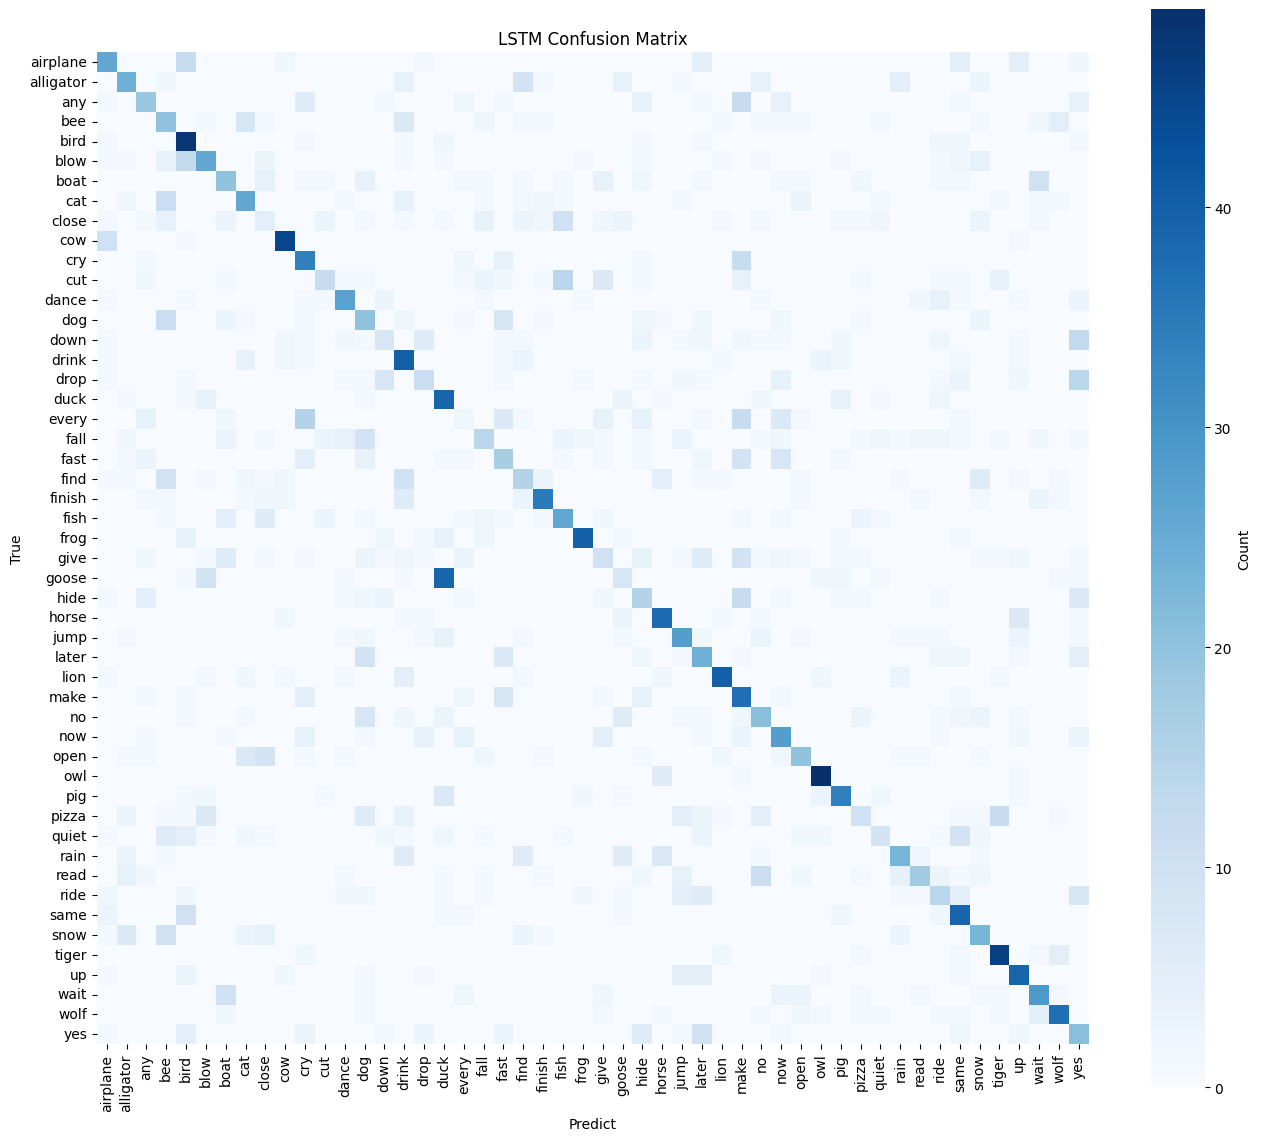


Top 10 confused pairs:
       goose confused for duck         : 39 times
       every confused for cry          : 15 times
         cut confused for fish         : 14 times
        drop confused for yes          : 14 times
        blow confused for bird         : 13 times
        down confused for yes          : 13 times
    airplane confused for bird         : 12 times
       every confused for make         : 12 times
         any confused for make         : 12 times
       pizza confused for tiger        : 12 times


In [18]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=classes, yticklabels=classes, cmap='Blues', square=True, cbar_kws={'label': 'Count'})
plt.xlabel('Predict')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.xticks(rotation=90)
plt.savefig('lstm_confusion_matrix.png', dpi=120)
plt.show()

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
print('\nTop 10 confused pairs:')
for idx in np.argsort(cm_no_diag.ravel())[-10:][::-1]:
    i, j = np.unravel_index(idx, cm_no_diag.shape)
    if cm_no_diag[i, j] > 0:
        print(f'{classes[i]:>12} confused for {classes[j]:<12} : {cm_no_diag[i, j]} times')